Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)

# Better plotting style
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 12

print("Libraries imported successfully.")

Libraries imported successfully.


Create Dataset

In [2]:
# Number of samples
n_samples = 200

# Input feature
X = np.linspace(-3, 3, n_samples).reshape(-1, 1)

# Gaussian noise
noise = np.random.normal(0, 0.1, n_samples).reshape(-1, 1)

# Target values
y = np.sin(X) + noise

print("Input shape :", X.shape)
print("Target shape:", y.shape)

Input shape : (200, 1)
Target shape: (200, 1)


Visualize Dataset

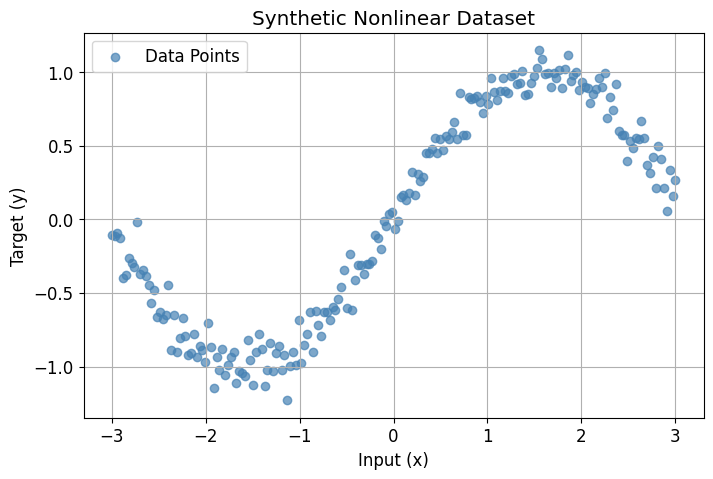

In [4]:
plt.figure()

plt.scatter(
    X,
    y,
    color="steelblue",
    alpha=0.7,
    label="Data Points"
)

plt.title("Synthetic Nonlinear Dataset")
plt.xlabel("Input (x)")
plt.ylabel("Target (y)")
plt.legend()
plt.grid(True)

plt.show()

Linear Regression Class

In [5]:
class LinearRegressionScratch:

    def __init__(self, learning_rate=0.01):
        self.lr = learning_rate

        # Initialize parameters
        self.w = np.random.randn(1, 1) * 0.01
        self.b = np.zeros((1,))

        self.loss_history = []


    # Prediction

    def predict(self, X):
        return X @ self.w + self.b


    # Mean Squared Error

    def compute_loss(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)


    # Compute Gradients

    def compute_gradients(self, X, y_true, y_pred):

        n = len(X)

        error = y_pred - y_true

        dw = (2 / n) * (X.T @ error)

        db = (2 / n) * np.sum(error)

        return dw, db


    # Gradient Descent Update

    def update_parameters(self, dw, db):

        self.w -= self.lr * dw
        self.b -= self.lr * db


    # Training Loop

    def fit(self, X, y, epochs=1000, print_every=100):

        for epoch in range(epochs):

            predictions = self.predict(X)

            loss = self.compute_loss(y, predictions)

            dw, db = self.compute_gradients(
                X,
                y,
                predictions
            )

            self.update_parameters(dw, db)

            self.loss_history.append(loss)

            if epoch % print_every == 0:
                print(f"Epoch {epoch:4d} | Loss = {loss:.6f}")

Train Linear Regression

In [6]:
# Train Linear Regression

linear_model = LinearRegressionScratch(
    learning_rate=0.01
)

linear_model.fit(
    X,
    y,
    epochs=1000,
    print_every=100
)

Epoch    0 | Loss = 0.569058
Epoch  100 | Loss = 0.183471
Epoch  200 | Loss = 0.183468
Epoch  300 | Loss = 0.183468
Epoch  400 | Loss = 0.183468
Epoch  500 | Loss = 0.183468
Epoch  600 | Loss = 0.183468
Epoch  700 | Loss = 0.183468
Epoch  800 | Loss = 0.183468
Epoch  900 | Loss = 0.183468


Visualize the Regression Line

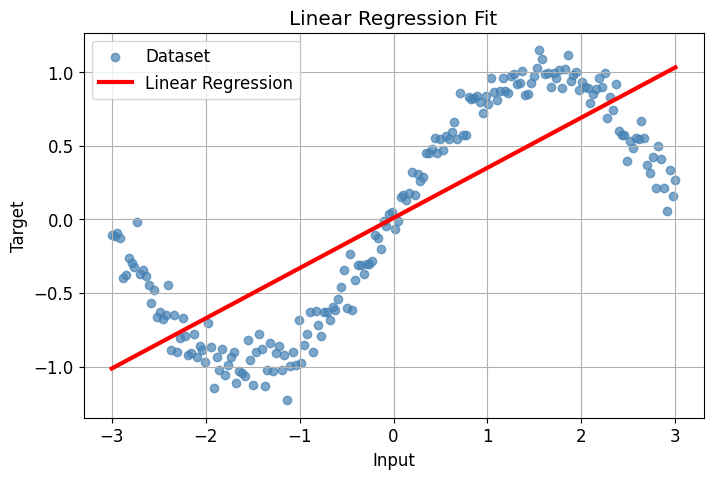

In [7]:
predictions = linear_model.predict(X)

plt.figure(figsize=(8,5))

plt.scatter(
    X,
    y,
    color="steelblue",
    alpha=0.7,
    label="Dataset"
)

plt.plot(
    X,
    predictions,
    color="red",
    linewidth=3,
    label="Linear Regression"
)

plt.title("Linear Regression Fit")
plt.xlabel("Input")
plt.ylabel("Target")
plt.legend()
plt.grid(True)

plt.show()

Plot the Loss Curve

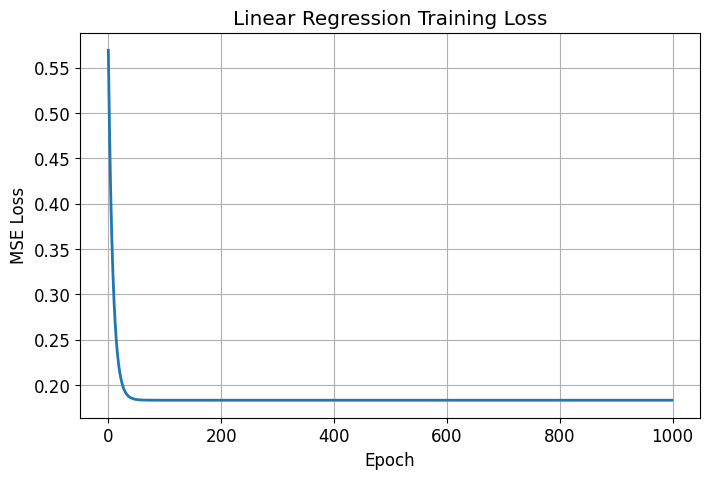

In [8]:
plt.figure(figsize=(8,5))

plt.plot(
    linear_model.loss_history,
    linewidth=2
)

plt.title("Linear Regression Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)

plt.show()

Evaluate the Model

In [9]:
final_predictions = linear_model.predict(X)

mse = np.mean((y - final_predictions) ** 2)

rmse = np.sqrt(mse)

mae = np.mean(np.abs(y - final_predictions))

print("=" * 40)
print("Linear Regression Performance")
print("=" * 40)

print(f"MSE  : {mse:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAE  : {mae:.6f}")

print("=" * 40)
print("Learned Parameters")
print("=" * 40)

print(f"Weight : {linear_model.w[0,0]:.6f}")
print(f"Bias   : {linear_model.b[0]:.6f}")

Linear Regression Performance
MSE  : 0.183468
RMSE : 0.428332
MAE  : 0.376370
Learned Parameters
Weight : 0.340744
Bias   : 0.008587


Activation Function

In [10]:
def tanh(x):
    return np.tanh(x)


def tanh_derivative(x):
    return 1 - np.tanh(x)**2

Neural Network Implementation

In [11]:
class NeuralNetworkScratch:

    def __init__(
        self,
        input_size=1,
        hidden_size=16,
        output_size=1,
        learning_rate=0.01
    ):

        self.lr = learning_rate


        # Xavier Initialization
        self.W1 = np.random.randn(
            input_size,
            hidden_size
        ) * np.sqrt(1/input_size)


        self.b1 = np.zeros(
            (1, hidden_size)
        )


        self.W2 = np.random.randn(
            hidden_size,
            output_size
        ) * np.sqrt(1/hidden_size)


        self.b2 = np.zeros(
            (1, output_size)
        )


        self.loss_history = []



    # -----------------------------
    # Forward Propagation
    # -----------------------------
    def forward(self, X):

        self.z1 = X @ self.W1 + self.b1

        self.h = tanh(self.z1)

        self.z2 = self.h @ self.W2 + self.b2

        y_hat = self.z2

        return y_hat



    # -----------------------------
    # Loss Function
    # -----------------------------
    def compute_loss(self, y, y_hat):

        return np.mean(
            (y-y_hat)**2
        )



    # -----------------------------
    # Backpropagation
    # -----------------------------
    def backward(self, X, y):

        n = len(X)


        # Output gradient

        dz2 = (
            2/n *
            (self.z2-y)
        )


        dW2 = self.h.T @ dz2

        db2 = np.sum(
            dz2,
            axis=0,
            keepdims=True
        )


        # Hidden layer gradient

        dz1 = (
            dz2 @ self.W2.T
        ) * tanh_derivative(
            self.z1
        )


        dW1 = X.T @ dz1


        db1 = np.sum(
            dz1,
            axis=0,
            keepdims=True
        )


        return dW1, db1, dW2, db2



    # -----------------------------
    # Parameter Update
    # -----------------------------
    def update(
        self,
        dW1,
        db1,
        dW2,
        db2
    ):

        self.W1 -= self.lr*dW1

        self.b1 -= self.lr*db1

        self.W2 -= self.lr*dW2

        self.b2 -= self.lr*db2



    # -----------------------------
    # Training
    # -----------------------------
    def fit(
        self,
        X,
        y,
        epochs=2000,
        print_every=200
    ):


        for epoch in range(epochs):


            prediction = self.forward(X)


            loss = self.compute_loss(
                y,
                prediction
            )


            gradients = self.backward(
                X,
                y
            )


            self.update(
                *gradients
            )


            self.loss_history.append(
                loss
            )


            if epoch % print_every == 0:

                print(
                    f"Epoch {epoch:4d} | Loss = {loss:.6f}"
                )

Train Neural Network

In [12]:
nn_model = NeuralNetworkScratch(
    hidden_size=16,
    learning_rate=0.01
)


nn_model.fit(
    X,
    y,
    epochs=2000,
    print_every=200
)

Epoch    0 | Loss = 1.520340
Epoch  200 | Loss = 0.056005
Epoch  400 | Loss = 0.038270
Epoch  600 | Loss = 0.031145
Epoch  800 | Loss = 0.028056
Epoch 1000 | Loss = 0.026558
Epoch 1200 | Loss = 0.025709
Epoch 1400 | Loss = 0.025135
Epoch 1600 | Loss = 0.024686
Epoch 1800 | Loss = 0.024300
